## Imports

In [15]:
import pickle
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
from lime import lime_tabular
import lightning as L
import torch
import torch.nn as nn
import torchmetrics
from sklearn.metrics import roc_curve, auc, balanced_accuracy_score, jaccard_score
from torchmetrics import Precision, Recall, F1Score
from lightning.pytorch.callbacks import Callback
from torchmetrics.functional import recall
from pnpl.datasets import LibriBrainSpeech
from torch.utils.data import DataLoader

## Speech detection model

In [17]:
class SpeechModel(nn.Module):
    """
    Parameters:
        input_dim (int): Number of channels/features in the input tensor (usually SENSORS_SPEECH_MASK)
        model_dim (int): Dimensionality for the intermediate model representation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        lstm_layers (int, optional): Number of layers in the LSTM module.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM; otherwise, a unidirectional LSTM.
        batch_norm (bool, optional): Indicates whether to use batch normalization.

    """
    def __init__(self, input_dim, model_dim, dropout_rate=0.3, lstm_layers = 1, bi_directional = False, batch_norm=False):
        super().__init__()
        self.conv = nn.Conv1d(
            in_channels=input_dim,
            out_channels=model_dim,
            kernel_size=3,
            padding=1,
        )
        self.lstm_layers = lstm_layers
        self.batch_norm = nn.BatchNorm1d(num_features=model_dim) if batch_norm else nn.Identity()
        self.conv_dropout = nn.Dropout(p=dropout_rate)
        self.lstm = nn.LSTM(
            input_size=model_dim,
            hidden_size=model_dim,
            num_layers=self.lstm_layers,
            dropout=dropout_rate,
            batch_first=True,
            bidirectional=bi_directional
        )
        self.lstm_dropout = nn.Dropout(p=dropout_rate)
        self.speech_classifier = nn.Linear(model_dim, 1)

    def forward(self, x):
        x = self.conv(x)
        x = self.batch_norm(x)
        x = self.conv_dropout(x)
        # LSTM expects (batch, seq_len, input_size)
        output, (h_n, c_n) = self.lstm(x.permute(0, 2, 1))
        last_layer_h_n = h_n
        if self.lstm_layers > 1:
            # handle more than one layer
            last_layer_h_n = h_n[-1, :, :]
            last_layer_h_n = last_layer_h_n.unsqueeze(0)
        output = self.lstm_dropout(last_layer_h_n)
        output = output.flatten(start_dim=0, end_dim=1)
        x = self.speech_classifier(output)
        return x

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs


In [18]:
class SpeechClassifier(L.LightningModule):
    """
    Parameters:
        input_dim (int): Number of input channels/features. This is passed to the underlying SpeechModel.
        model_dim (int): Dimensionality of the intermediate model representation.
        learning_rate (float, optional): Learning rate for the optimizer.
        weight_decay (float, optional): Weight decay for the optimizer.
        batch_size (int, optional): Batch size used during training and evaluation.
        dropout_rate (float, optional): Dropout probability applied after convolutional and LSTM layers.
        smoothing (float, optional): Label smoothing factor applied in the BCEWithLogits loss.
        pos_weight (float, optional): Weight for the positive class in the BCEWithLogits loss.
        batch_norm (bool, optional): Indicates whether to use batch normalization.
        lstm_layers (int, optional): Number of layers in the LSTM module within the SpeechModel.
        bi_directional (bool, optional): If True, uses a bidirectional LSTM in the SpeechModel; otherwise, uses a unidirectional LSTM.
    """

    def __init__(self, input_dim, model_dim, learning_rate=1e-3, weight_decay=0.01, batch_size=32, dropout_rate=0.3, smoothing=0.1, pos_weight = 1.0 , batch_norm = False, lstm_layers = 1, bi_directional = False):
        super().__init__()
        self.save_hyperparameters()

        self.learning_rate = learning_rate
        self.weight_decay = weight_decay
        self.batch_size = batch_size
        self.model = SpeechModel(input_dim, model_dim, dropout_rate=dropout_rate, lstm_layers=lstm_layers, bi_directional=bi_directional, batch_norm=batch_norm)

        self.loss_fn = BCEWithLogitsLossWithSmoothing(smoothing=smoothing, pos_weight = pos_weight)

        self.val_step_outputs = []
        self.test_step_outputs = {}


    def forward(self, x):
        return self.model(x)

    def predict_proba(self, x):
        logits = self.forward(x)
        probs = torch.sigmoid(logits)
        class_probs = torch.zeros((x.shape[0], 2))
        for i in range(x.shape[0]):
            class_probs[i, 0] = probs[i]
            class_probs[i, 1] = 1-probs[i]
        return class_probs

    def _shared_eval_step(self, batch, stage):
        x = batch[0]
        y = batch[1] # (batch, seq_len)

        logits = self(x)
        loss = self.loss_fn(logits, y.unsqueeze(1).float())
        probs = torch.sigmoid(logits)
        y_probs = probs.detach().cpu()

        y_true = batch[1].detach().cpu()
        meg = x.detach().cpu()

        self.log(f'{stage}_loss', loss, on_step=False, on_epoch=True, batch_size=self.batch_size)
        return loss


    def training_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "train")


    def validation_step(self, batch, batch_idx):
        return self._shared_eval_step(batch, "val")


    def test_step(self, batch, batch_idx):
        x = batch[0]
        y = batch[1]  # (batch, seq_len)

        # ugly, taking care of only one label
        if len(y.shape) != 1:
            y = y.flatten(start_dim=0, end_dim=1).view(-1, 1)  # (batch, seq_len) -> (batch * seq_len, 1)
        else:
            y = y.unsqueeze(1)

        logits = self(x)
        loss = self.loss_fn(logits, y.float())
        probs = torch.sigmoid(logits)

        # Append data to the defaultdict
        # Ensure keys exist before appending
        if "y_probs" not in self.test_step_outputs:
            self.test_step_outputs["y_probs"] = []
        if "y_true" not in self.test_step_outputs:
            self.test_step_outputs["y_true"] = []
        if "meg" not in self.test_step_outputs:
            self.test_step_outputs["meg"] = []

        # Append data
        if y.shape[-1] != 1:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], x.shape[-1]).cpu())  # (batch, seq_len)
        else:
            self.test_step_outputs["y_probs"].extend(
                probs.detach().view(x.shape[0], 1).cpu())  # (batch, seq_len)

        self.test_step_outputs["y_true"].extend(batch[1].detach().cpu())  # (batch, seq_len)
        self.test_step_outputs["meg"].extend(x.detach().cpu())  # MEG data (batch, channels, seq_len)

        return self._shared_eval_step(batch, "test")

    def configure_optimizers(self):
        optimizer = torch.optim.AdamW(self.parameters(), lr=self.learning_rate, weight_decay=self.weight_decay)
        return optimizer


class BCEWithLogitsLossWithSmoothing(nn.Module):
    def __init__(self, smoothing=0.1, pos_weight = 1.0):
        """
        Binary Cross-Entropy Loss with Deterministic Label Smoothing.

        Parameters:
            smoothing (float): Smoothing factor. Must be between 0 and 1.
            pos_weight (float): Weight for the positive class.
        """
        super().__init__()
        self.smoothing = smoothing
        self.bce_loss = nn.BCEWithLogitsLoss(pos_weight=torch.tensor([pos_weight]))

    def forward(self, logits, target):
        target = target.float()  # Ensure target is a float tensor
        target_smoothed = target * (1 - self.smoothing) + self.smoothing * 0.5
        return self.bce_loss(logits, target_smoothed)

## Load model

In [19]:
# Setup checkpoint path
checkpoint_path = "speech_model.ckpt"

# Set a fixed seed for reproducibility (just in case)
L.seed_everything(42)

# Load the SpeechClassifier model from checkpoint
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]
model = SpeechClassifier(
    input_dim=len(SENSORS_SPEECH_MASK),
    model_dim=100,
    learning_rate=1e-3,
    dropout_rate=0.5,
    lstm_layers=2,
    weight_decay=0.01,
    batch_norm=False,
    bi_directional=False
)

# Initialize trainer and test loaded model
trainer = L.Trainer(devices="auto")

Seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


## Load data

In [20]:
# Set up base path for dataset and related files (base_path is assumed to be set in the cells below!)
base_path = "./libribrain"
try:
    import google.colab  # This module is only available in Colab.
    in_colab = True
    base_path = "/content"  # This is the folder displayed in the Colab sidebar
except ImportError:
    in_colab = False

num_workers = 2 if in_colab else 0

# train on one session
train_run_keys = [("0","1","Sherlock7","1")]
train_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=train_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
train_loader = DataLoader(train_data, batch_size=32, shuffle=False, num_workers=num_workers)

# val on one session
val_run_keys = [("0","2","Sherlock7","1")]
val_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=val_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
val_loader = DataLoader(val_data, batch_size=32, shuffle=False, num_workers=num_workers)

# For testing, we'll use all sessions from Sherlock 7
test_run_keys = [("0","3","Sherlock7","1")]
test_data = LibriBrainSpeech(
  data_path=f"{base_path}/data/",
  include_run_keys=test_run_keys,
  standardize=True,
  tmin=0.0,
  tmax=0.8,
  preload_files = True
)
test_loader = DataLoader(test_data, batch_size=32, shuffle=False, num_workers=num_workers)

In [21]:
# These are the sensors we identified as being particularly useful
SENSORS_SPEECH_MASK = [18, 20, 22, 23, 45, 120, 138, 140, 142, 143, 145,
                       146, 147, 149, 175, 176, 177, 179, 180, 198, 271, 272, 275]

class FilteredDataset(torch.utils.data.Dataset):
    """
    Parameters:
        dataset: LibriBrain dataset.
        limit_samples (int, optional): If provided, limits the length of the dataset to this
                          number of samples.
        speech_silence_only (bool, optional): If True, only includes segments that are either
                          purely speech or purely silence (with additional balancing).
        apply_sensors_speech_mask (bool, optional): If True, applies a fixed sensor mask to the sensor
                          data in each sample.
    """
    def __init__(self,
                 dataset,
                 limit_samples=None,
                 disable=False,
                 apply_sensors_speech_mask=True):
        self.dataset = dataset
        self.limit_samples = limit_samples
        self.apply_sensors_speech_mask = apply_sensors_speech_mask

        # These are the sensors we identified:
        self.sensors_speech_mask = SENSORS_SPEECH_MASK

        self.balanced_indices = list(range(len(dataset.samples)))
        # Shuffle the indices
        self.balanced_indices = random.sample(self.balanced_indices, len(self.balanced_indices))

    def __len__(self):
        """Returns the number of samples in the filtered dataset."""
        if self.limit_samples is not None:
            return self.limit_samples
        return len(self.balanced_indices)

    def __getitem__(self, index):
        # Map index to the original dataset using balanced indices
        original_idx = self.balanced_indices[index]
        if self.apply_sensors_speech_mask:
            sensors = self.dataset[original_idx][0][self.sensors_speech_mask]
        else:
            sensors = self.dataset[original_idx][0][:]
        label_from_the_middle_idx = self.dataset[original_idx][1].shape[0] // 2
        return [sensors, self.dataset[original_idx][1][label_from_the_middle_idx]]


# Conditionally set num_workers to avoid multiprocessing issues (try increasing if performance is problematic)
num_workers = 2 if in_colab else 0

train_data_filtered = FilteredDataset(train_data)
train_loader_filtered = DataLoader(train_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

val_data_filtered = FilteredDataset(val_data)
val_loader_filtered = DataLoader(val_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

test_data_filtered = FilteredDataset(test_data)
test_loader_filtered = DataLoader(test_data_filtered, batch_size=32, shuffle=False, num_workers=num_workers)

## Get first batch for testing

In [22]:
first_batch = next(iter(test_loader_filtered))
inputs, labels = first_batch
print(inputs.shape, labels.shape)

torch.Size([32, 23, 200]) torch.Size([32])


## Validate predict_proba function in model

In [19]:
model.eval()
class_probs = model.predict_proba(inputs)
print(class_probs.shape)
class_probs

torch.Size([32, 2])


tensor([[0.4975, 0.5025],
        [0.4935, 0.5065],
        [0.4937, 0.5063],
        [0.4918, 0.5082],
        [0.4940, 0.5060],
        [0.4945, 0.5055],
        [0.4946, 0.5054],
        [0.4919, 0.5081],
        [0.4940, 0.5060],
        [0.4993, 0.5007],
        [0.4947, 0.5053],
        [0.4916, 0.5084],
        [0.4898, 0.5102],
        [0.4905, 0.5095],
        [0.4946, 0.5054],
        [0.4974, 0.5026],
        [0.4931, 0.5069],
        [0.4938, 0.5062],
        [0.4896, 0.5104],
        [0.4931, 0.5069],
        [0.4979, 0.5021],
        [0.4942, 0.5058],
        [0.4934, 0.5066],
        [0.4945, 0.5055],
        [0.4975, 0.5025],
        [0.4934, 0.5066],
        [0.4971, 0.5029],
        [0.4937, 0.5063],
        [0.4934, 0.5066],
        [0.4943, 0.5057],
        [0.4925, 0.5075],
        [0.4950, 0.5050]], grad_fn=<CopySlices>)

In [13]:
model.forward(inputs).shape

torch.Size([32, 1])

## Visualize signal

In [38]:
inds_1 = np.where(labels==1)[0]
num_ones = len(inds_1)

inds_0 = np.where(labels==0)[0]
num_zeros = len(inds_0)

ave_signal_1 = np.zeros((num_ones, 200))
ave_signal_0 = np.zeros((num_zeros, 200))
cntr = 0
for i in inds_1:
  ave_signal_1[cntr] =  inputs[i, :, :].mean(axis=0)
  cntr+=1
cntr = 0
for i in inds_0:
  ave_signal_0[cntr] =  inputs[i, :, :].mean(axis=0)
  cntr+=1


In [41]:
print(ave_signal_0.shape, ave_signal_1.shape)

(11, 200) (21, 200)


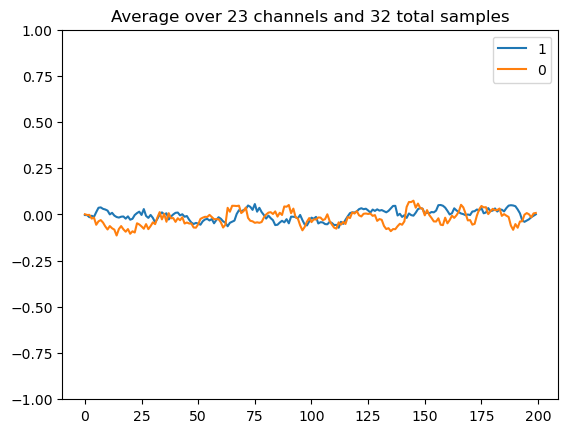

In [43]:
plt.figure()
plt.plot(np.arange(inputs.shape[-1]), ave_signal_1.mean(axis=0), label="1")
plt.plot(np.arange(inputs.shape[-1]), ave_signal_0.mean(axis=0), label="0")
plt.legend()
plt.title("Average over 23 channels and 32 total samples")
plt.ylim([-1,1])
plt.show()

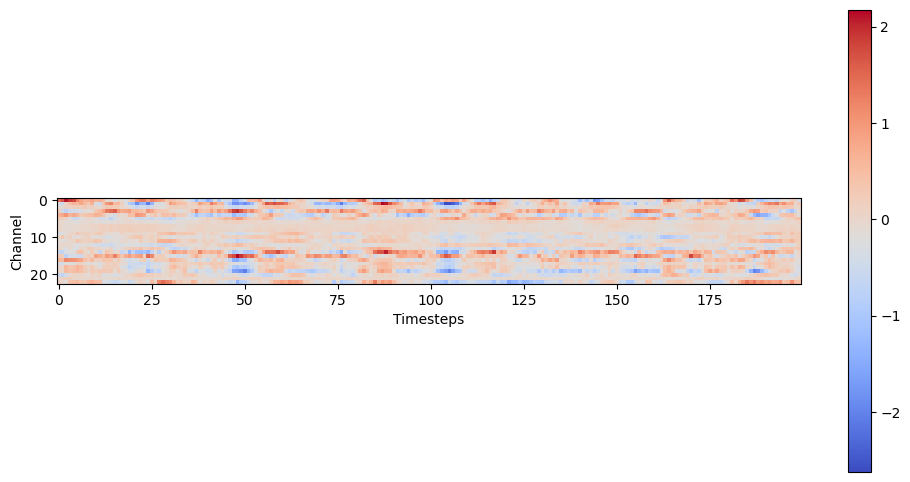

In [44]:
plt.figure(figsize=(12,6))
plt.imshow(inputs[0],cmap="coolwarm",label="Speech")
plt.colorbar()
plt.xlabel("Timesteps")
plt.ylabel("Channel")
plt.show()

In [65]:
total_ave_signal_0 = np.zeros((1, 200))
n_0s = 0
total_ave_signal_1 = np.zeros((1, 200))
n_1s = 0
for curr_inputs, curr_labels in iter(train_loader_filtered):   
  inds_1 = np.where(curr_labels==1)[0]
  num_ones = len(inds_1)
  n_1s += num_ones

  inds_0 = np.where(curr_labels==0)[0]
  num_zeros = len(inds_0)
  n_0s += num_zeros

  ave_signal_1 = np.zeros((num_ones, 200))
  ave_signal_0 = np.zeros((num_zeros, 200))
  cntr = 0
  for i in inds_1:
    ave_signal_1[cntr] =  inputs[i, :, :].mean(axis=0)
    cntr+=1
  cntr = 0
  for i in inds_0:
    ave_signal_0[cntr] =  inputs[i, :, :].mean(axis=0)
    cntr+=1
  total_ave_signal_0 = np.concatenate((total_ave_signal_0, ave_signal_0), axis=0)
  total_ave_signal_1 = np.concatenate((total_ave_signal_1, ave_signal_1), axis=0)

total_ave_signal_0 = total_ave_signal_0[1:].mean(axis=0)
total_ave_signal_1 = total_ave_signal_1[1:].mean(axis=0)
print(n_0s, n_1s)


363 1262


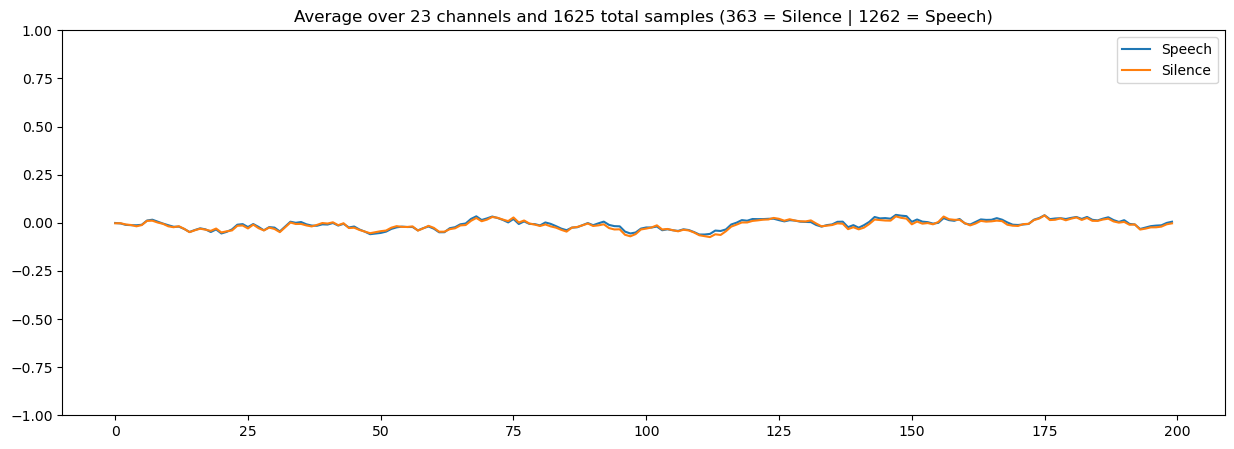

In [66]:
plt.figure(figsize=(15,5))
plt.plot(np.arange(200), total_ave_signal_1, label="Speech")
plt.plot(np.arange(200), total_ave_signal_0, label="Silence")
plt.legend()
plt.title(f"Average over 23 channels and {n_0s+n_1s} total samples ({n_0s} = Silence | {n_1s} = Speech)")
plt.ylim([-1,1])
plt.show()

## Train

In [23]:
# training
trainer = L.Trainer(
    devices="auto",
    max_epochs=10,
    enable_checkpointing=True
)
trainer.fit(model, train_loader_filtered, val_loader_filtered)

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs

  | Name    | Type                           | Params | Mode 
-------------------------------------------------------------------
0 | model   | SpeechModel                    | 168 K  | train
1 | loss_fn | BCEWithLogitsLossWithSmoothing | 0      | train
-------------------------------------------------------------------
168 K     Trainable params
0         Non-trainable params
168 K     Total params
0.675     Total estimated model params size (MB)
9         Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.
/opt/miniconda3/envs/pytorch_env/lib/python3.13/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=9` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=10` reached.


## Lime (tabular)

In [26]:
n_timesteps = inputs.shape[-1]
n_features = len(SENSORS_SPEECH_MASK)

explainer = lime_tabular.RecurrentTabularExplainer(
    np.array(inputs),
    mode="classification",
    training_labels = np.array(labels),
    feature_names = [f"Channel{i}" for i in range(n_features)],
    discretize_continuous = False,
    class_names = ["Silence", "Speech"],
    discretizer = 'decile'
)

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_44269/449659509.py:5: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(inputs),
/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_44269/449659509.py:7: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  training_labels = np.array(labels),


In [27]:
exp = explainer.explain_instance(
    np.array(inputs[0,:,:]),
    model.predict_proba,
    num_features=n_features,
    labels=(1,)
  )

/var/folders/pr/0jl9zy5j5nvcs0ycl3xdjjmm0000gn/T/ipykernel_44269/2773915663.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  np.array(inputs[0,:,:]),


TypeError: conv1d() received an invalid combination of arguments - got (numpy.ndarray, Parameter, Parameter, tuple, tuple, tuple, int), but expected one of:
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, tuple of ints padding = 0, tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !Parameter!, !tuple of (int,)!, !tuple of (int,)!, !tuple of (int,)!, !int!)
 * (Tensor input, Tensor weight, Tensor bias = None, tuple of ints stride = 1, str padding = "valid", tuple of ints dilation = 1, int groups = 1)
      didn't match because some of the arguments have invalid types: (!numpy.ndarray!, !Parameter!, !Parameter!, !tuple of (int,)!, !tuple of (int,)!, !tuple of (int,)!, !int!)


## TSInterpret

In [32]:
from TSInterpret.InterpretabilityModels.Saliency.TSR import TSR

n_timesteps = inputs.shape[-1]
n_features = len(SENSORS_SPEECH_MASK)
curr_input = np.array([inputs[0, :, :]]) # dims = 1 x 23 x 200

int_mod = TSR(
    model,
    n_timesteps,
    n_features,
    method='IG', # Integrated Gradients (IG)
    mode="feat" # second dim is 'time' or 'feat'
)
item = curr_input
label = labels[0]

exp = int_mod.explain(item, labels=label, TSR =True)

IndexError: index 1 is out of bounds for dimension 1 with size 1

In [ ]:
%matplotlib inline
int_mod.plot(item,exp)

In [37]:
from TSInterpret.InterpretabilityModels.leftist.leftist import LEFTIST

leftist = LEFTIST(
    model,
    (np.array(inputs), np.array(labels)),
    mode='feat',
    backend='PYT',
    learning_process_name='Lime',
    transform_name="background",
    explanation_size=1,
    nb_neighbors=1000
  )

explained_instance = np.array([inputs[0, :, :]]) # dims = 1 x 23 x 200
label = np.array(labels[0])

explanations = leftist.explain(explained_instance,label)

RuntimeError: Given groups=1, weight of size [100, 23, 3], expected input[23000, 1, 200] to have 23 channels, but got 1 channels instead